<a href="https://colab.research.google.com/github/sanvi-g07/ml-zoomcamp/blob/main/06_credit_risk_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Get data

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import roc_auc_score
from sklearn.tree import export_text
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

In [4]:
data = 'https://raw.githubusercontent.com/gastonstat/CreditScoring/refs/heads/master/CreditScoring.csv'

In [5]:
!wget $data

--2026-08-13 17:12:42--  https://raw.githubusercontent.com/gastonstat/CreditScoring/refs/heads/master/CreditScoring.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182489 (178K) [text/plain]
Saving to: ‘CreditScoring.csv’

CreditScoring.csv   100%[===================>] 178.21K  --.-KB/s    in 0.004s  

2026-08-13 17:12:42 (40.2 MB/s) - ‘CreditScoring.csv’ saved [182489/182489]



In [6]:
df = pd.read_csv("CreditScoring.csv")

In [7]:
df

,Status,Seniority,Home,Time,Age,Marital,Records,Job,Expenses,Income,Assets,Debt,Amount,Price
0,1,9,1,60,30,2,1,3,73,129,0,0,800,846
1,1,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,2,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,1,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,1,0,1,36,26,1,1,1,46,107,0,0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450,2,1,1,60,39,2,1,1,69,92,0,0,900,1020
4451,1,22,2,60,46,2,1,1,60,75,3000,600,950,1263
4452,2,0,2,24,37,2,1,2,60,90,3500,0,500,963
4453,1,0,1,48,23,1,1,3,49,140,0,0,550,550


#Data cleaning

In [8]:
df.columns = df.columns.str.lower()

In [9]:
status_values = {
    1: 'ok',
    2: 'default',
    0:'unk'
}

df.status = df.status.map(status_values)

In [10]:
df.head()

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,1,60,30,2,1,3,73,129,0,0,800,846
1,ok,17,1,60,58,3,1,1,48,131,0,0,1000,1658
2,default,10,2,36,46,2,2,3,90,200,3000,0,2000,2985
3,ok,0,1,60,24,1,1,1,63,182,2500,0,900,1325
4,ok,0,1,36,26,1,1,1,46,107,0,0,310,910


In [11]:
home_values = {
    1: 'rent',
    2: 'owner',
    3: 'private',
    4: 'ignore',
    5: 'parents',
    6: 'other',
    0: 'unk'
}

df.home = df.home.map(home_values)

marital_values = {
    1: 'single',
    2: 'married',
    3: 'widow',
    4: 'separated',
    5: 'divorced',
    0: 'unk'
}

df.marital = df.marital.map(marital_values)

records_values = {
    1: 'no',
    2: 'yes',
    0: 'unk'
}

df.records = df.records.map(records_values)

job_values = {
    1: 'fixed',
    2: 'partime',
    3: 'freelance',
    4: 'others',
    0: 'unk'
}

df.job = df.job.map(job_values)

In [12]:
df

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,9,rent,60,30,married,no,freelance,73,129,0,0,800,846
1,ok,17,rent,60,58,widow,no,fixed,48,131,0,0,1000,1658
2,default,10,owner,36,46,married,yes,freelance,90,200,3000,0,2000,2985
3,ok,0,rent,60,24,single,no,fixed,63,182,2500,0,900,1325
4,ok,0,rent,36,26,single,no,fixed,46,107,0,0,310,910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4450,default,1,rent,60,39,married,no,fixed,69,92,0,0,900,1020
4451,ok,22,owner,60,46,married,no,fixed,60,75,3000,600,950,1263
4452,default,0,owner,24,37,married,no,partime,60,90,3500,0,500,963
4453,ok,0,rent,48,23,single,no,freelance,49,140,0,0,550,550


In [13]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,763317.0,1060341.0,404382.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,8703625.0,10217569.0,6344253.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3500.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,166.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,99999999.0,99999999.0,99999999.0,5000.0,11140.0


In [14]:
for c in ['income', 'assets', 'debt']:
  df[c] = df[c].replace(to_replace=99999999.0, value=np.nan)

In [15]:
df.describe().round()

,seniority,time,age,expenses,income,assets,debt,amount,price
count,4455.0,4455.0,4455.0,4455.0,4421.0,4408.0,4437.0,4455.0,4455.0
mean,8.0,46.0,37.0,56.0,131.0,5403.0,343.0,1039.0,1463.0
std,8.0,15.0,11.0,20.0,86.0,11573.0,1246.0,475.0,628.0
min,0.0,6.0,18.0,35.0,0.0,0.0,0.0,100.0,105.0
25%,2.0,36.0,28.0,35.0,80.0,0.0,0.0,700.0,1118.0
50%,5.0,48.0,36.0,51.0,120.0,3000.0,0.0,1000.0,1400.0
75%,12.0,60.0,45.0,72.0,165.0,6000.0,0.0,1300.0,1692.0
max,48.0,72.0,68.0,180.0,959.0,300000.0,30000.0,5000.0,11140.0


In [16]:
df.status.value_counts()

,count
status,
ok,3200
default,1254
unk,1


In [17]:
df = df[df.status != 'unk'].reset_index(drop=True)

In [18]:
from sklearn.model_selection import train_test_split

df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

In [19]:
len(df_full_train), len(df_train), len(df_val), len(df_test)

(3563, 2672, 891, 891)

In [20]:
df_full_train = df_full_train.reset_index(drop=True)
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [21]:
df_train.status

,status
0,default
1,default
2,ok
3,default
4,ok
...,...
2667,ok
2668,ok
2669,ok
2670,ok


In [22]:
y_train = (df_train.status == 'default').astype(int)
y_val = (df_val.status == 'default').astype(int)
y_test = (df_test.status == 'default').astype(int)

In [23]:
del df_train['status']
del df_val['status']
del df_test['status']

In [24]:
df_train

,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,10,owner,36,36,married,no,freelance,75,0.0,10000.0,0.0,1000,1400
1,6,parents,48,32,single,yes,fixed,35,85.0,0.0,0.0,1100,1330
2,1,parents,48,40,married,no,fixed,75,121.0,0.0,0.0,1320,1600
3,1,parents,48,23,single,no,partime,35,72.0,0.0,0.0,1078,1079
4,5,owner,36,46,married,no,freelance,60,100.0,4000.0,0.0,1100,1897
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2667,18,private,36,45,married,no,fixed,45,220.0,20000.0,0.0,800,1600
2668,7,private,60,29,married,no,fixed,60,51.0,3500.0,500.0,1000,1290
2669,1,parents,24,19,single,no,fixed,35,28.0,0.0,0.0,400,600
2670,15,owner,48,43,married,no,freelance,60,100.0,18000.0,0.0,2500,2976


#Decision Tree

##Train Decision Tree

In [25]:
train_dicts = df_train.fillna(0).to_dict(orient='records')
train_dicts[:5]

[{'seniority': 10,
  'home': 'owner',
  'time': 36,
  'age': 36,
  'marital': 'married',
  'records': 'no',
  'job': 'freelance',
  'expenses': 75,
  'income': 0.0,
  'assets': 10000.0,
  'debt': 0.0,
  'amount': 1000,
  'price': 1400},
 {'seniority': 6,
  'home': 'parents',
  'time': 48,
  'age': 32,
  'marital': 'single',
  'records': 'yes',
  'job': 'fixed',
  'expenses': 35,
  'income': 85.0,
  'assets': 0.0,
  'debt': 0.0,
  'amount': 1100,
  'price': 1330},
 {'seniority': 1,
  'home': 'parents',
  'time': 48,
  'age': 40,
  'marital': 'married',
  'records': 'no',
  'job': 'fixed',
  'expenses': 75,
  'income': 121.0,
  'assets': 0.0,
  'debt': 0.0,
  'amount': 1320,
  'price': 1600},
 {'seniority': 1,
  'home': 'parents',
  'time': 48,
  'age': 23,
  'marital': 'single',
  'records': 'no',
  'job': 'partime',
  'expenses': 35,
  'income': 72.0,
  'assets': 0.0,
  'debt': 0.0,
  'amount': 1078,
  'price': 1079},
 {'seniority': 5,
  'home': 'owner',
  'time': 36,
  'age': 46,
  'm

In [26]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_train

array([[3.60e+01, 1.00e+03, 1.00e+04, ..., 0.00e+00, 1.00e+01, 3.60e+01],
       [3.20e+01, 1.10e+03, 0.00e+00, ..., 1.00e+00, 6.00e+00, 4.80e+01],
       [4.00e+01, 1.32e+03, 0.00e+00, ..., 0.00e+00, 1.00e+00, 4.80e+01],
       ...,
       [1.90e+01, 4.00e+02, 0.00e+00, ..., 0.00e+00, 1.00e+00, 2.40e+01],
       [4.30e+01, 2.50e+03, 1.80e+04, ..., 0.00e+00, 1.50e+01, 4.80e+01],
       [2.70e+01, 4.50e+02, 5.00e+03, ..., 1.00e+00, 1.20e+01, 4.80e+01]])

In [27]:
dv.get_feature_names_out()

array(['age', 'amount', 'assets', 'debt', 'expenses', 'home=ignore',
       'home=other', 'home=owner', 'home=parents', 'home=private',
       'home=rent', 'home=unk', 'income', 'job=fixed', 'job=freelance',
       'job=others', 'job=partime', 'job=unk', 'marital=divorced',
       'marital=married', 'marital=separated', 'marital=single',
       'marital=unk', 'marital=widow', 'price', 'records=no',
       'records=yes', 'seniority', 'time'], dtype=object)

In [28]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

DecisionTreeClassifier()

##Validate model

In [29]:
val_dicts = df_val.fillna(0).to_dict(orient='records')
X_val = dv.transform(val_dicts)

In [30]:
y_pred_val = dt.predict_proba(X_val)[:, 1]
y_pred_val[:10]

array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0.])

In [31]:
roc_auc_score(y_val, y_pred_val)

np.float64(0.650062967716936)

In [32]:
y_pred_train = dt.predict_proba(X_train)[:, 1]
y_pred_train[:10]

array([1., 1., 0., 1., 0., 1., 0., 1., 1., 1.])

In [33]:
roc_auc_score(y_train, y_pred_train)

np.float64(1.0)

##Retrain and validate tree (reduce depth)

In [34]:
dt = DecisionTreeClassifier(max_depth=3)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3)

In [35]:
y_pred_train = dt.predict_proba(X_train)[:, 1]
auc_train = roc_auc_score(y_train, y_pred_train)
print('Train AUC: ', auc_train)

y_pred_val = dt.predict_proba(X_val)[:, 1]
auc_val = roc_auc_score(y_val, y_pred_val)
print('Val AUC: ', auc_val)

Train AUC:  0.7761016984958594
Val AUC:  0.7389079944782155


In [36]:
export_text(dt)

'|--- feature_25 <= 0.50\n|   |--- feature_27 <= 6.50\n|   |   |--- feature_1 <= 862.50\n|   |   |   |--- class: 0\n|   |   |--- feature_1 >  862.50\n|   |   |   |--- class: 1\n|   |--- feature_27 >  6.50\n|   |   |--- feature_12 <= 103.50\n|   |   |   |--- class: 1\n|   |   |--- feature_12 >  103.50\n|   |   |   |--- class: 0\n|--- feature_25 >  0.50\n|   |--- feature_16 <= 0.50\n|   |   |--- feature_12 <= 74.50\n|   |   |   |--- class: 0\n|   |   |--- feature_12 >  74.50\n|   |   |   |--- class: 0\n|   |--- feature_16 >  0.50\n|   |   |--- feature_2 <= 8750.00\n|   |   |   |--- class: 1\n|   |   |--- feature_2 >  8750.00\n|   |   |   |--- class: 0\n'

##Decision Tree Parameter Tuning

In [37]:
print("Max depth -> Train AUC, Val AUC")
for d in [1, 2, 3, 4, 5, 6, 10, 15, 20, None]:
  dt = DecisionTreeClassifier(max_depth=d)
  dt.fit(X_train, y_train)

  y_pred_train = dt.predict_proba(X_train)[:, 1]
  auc_train = roc_auc_score(y_train, y_pred_train)
  y_pred_val = dt.predict_proba(X_val)[:, 1]
  auc_val = roc_auc_score(y_val, y_pred_val)

  print('%9s -> %.3f %.3f' % (d, auc_train, auc_val))

Max depth -> Train AUC, Val AUC
        1 -> 0.628 0.606
        2 -> 0.705 0.669
        3 -> 0.776 0.739
        4 -> 0.816 0.761
        5 -> 0.843 0.767
        6 -> 0.874 0.750
       10 -> 0.963 0.678
       15 -> 0.999 0.667
       20 -> 1.000 0.655
     None -> 1.000 0.655


In [38]:
scores = []
for d in [4, 5, 6, 7, 10, 15, 20, None]:
  for s in [1, 2, 5, 10, 15, 20, 100, 200, 500]:
    dt = DecisionTreeClassifier(max_depth=d, min_samples_leaf=s)
    dt.fit(X_train, y_train)

    y_pred_val = dt.predict_proba(X_val)[:, 1]
    auc_val = roc_auc_score(y_val, y_pred_val)

    scores.append((d, s, auc_val))

In [39]:
df_scores = pd.DataFrame(scores, columns=['max_depth', 'min_samples_leaf', 'auc'])
df_scores

,max_depth,min_samples_leaf,auc
0,4.0,1,0.761283
1,4.0,2,0.761283
2,4.0,5,0.761283
3,4.0,10,0.761283
4,4.0,15,0.763726
...,...,...,...
67,NaN,15,0.788077
68,NaN,20,0.780558
69,NaN,100,0.779725
70,NaN,200,0.768479


In [40]:
df_scores.sort_values(by='auc', ascending=False)

,max_depth,min_samples_leaf,auc
40,10.0,15,0.788995
67,NaN,15,0.788077
49,15.0,15,0.787599
58,20.0,15,0.786367
22,6.0,15,0.785080
...,...,...,...
53,15.0,500,0.679842
71,NaN,500,0.679842
54,20.0,1,0.656124
63,NaN,1,0.650420


In [41]:
df_scores_pivot = df_scores.pivot(index='min_samples_leaf', columns=['max_depth'], values=['auc'])
df_scores_pivot

auc                                                    \
max_depth              NaN      4.0       5.0       6.0       7.0       10.0   
min_samples_leaf                                                               
1                 0.650420  0.761283  0.766938  0.758625  0.738390  0.695403   
2                 0.691122  0.761283  0.766496  0.757626  0.759076  0.727250   
5                 0.715374  0.761283  0.767755  0.759981  0.757051  0.732357   
10                0.765485  0.761283  0.761809  0.778299  0.763686  0.764782   
15                0.788077  0.763726  0.772405  0.785080  0.779319  0.788995   
20                0.780558  0.760910  0.774028  0.773982  0.779489  0.784330   
100               0.779725  0.755937  0.763384  0.776434  0.779583  0.779725   
200               0.768479  0.747260  0.759073  0.768267  0.768479  0.768479   
500               0.679842  0.679842  0.679842  0.679842  0.679842  0.679842   

                                      
max_depth             15.0      20.0  
min_samples_leaf                      
1                 0.642558  0.656124  
2                 0.683947  0.683693  
5                 0.717538  0.716203  
10                0.761013  0.764134  
15                0.787599  0.786367  
20                0.783585  0.780518  
100               0.779725  0.779474  
200               0.768479  0.768479  
500               0.679842  0.679842

<Axes: xlabel='None-max_depth', ylabel='min_samples_leaf'>

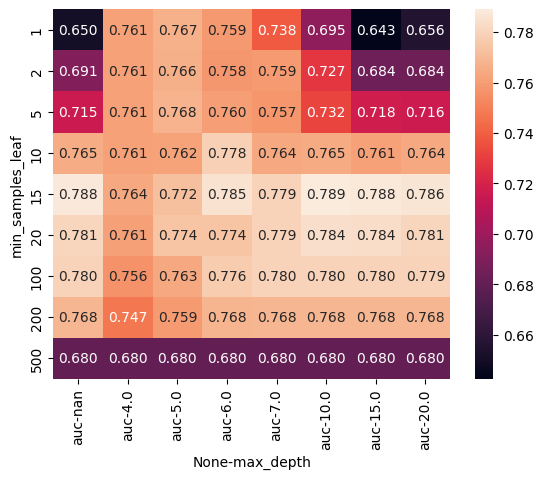

In [42]:
sns.heatmap(df_scores_pivot, annot=True, fmt='.3f')

#Random Forest

In [43]:
rf = RandomForestClassifier(n_estimators=10, random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=10, random_state=1)

In [44]:
y_pred_val = rf.predict_proba(X_val)[:, 1]

In [45]:
roc_auc_score(y_val, y_pred_val)

np.float64(0.7744726453706618)

##Tune Random Forest hyperparameters

In [46]:
scores = []

for d in [5, 10, 15]:
  for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=1)
    rf.fit(X_train, y_train)
    y_pred_val = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_val)
    scores.append((d, n, auc))

In [47]:
columns = ['max_depth', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores

,max_depth,n_estimators,auc
0,5,10,0.787699
1,5,20,0.797731
2,5,30,0.800305
3,5,40,0.799708
4,5,50,0.799878
5,5,60,0.801167
6,5,70,0.802251
7,5,80,0.803244
8,5,90,0.803616
9,5,100,0.804452


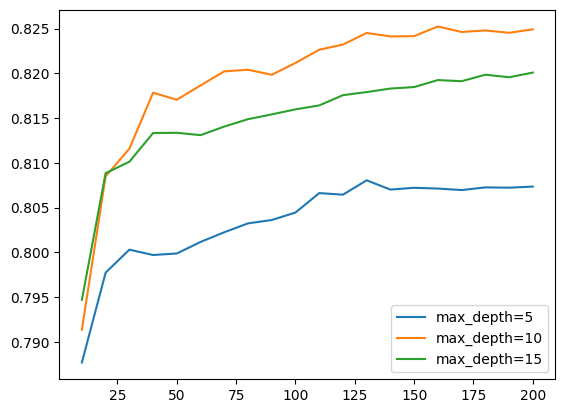

In [48]:
for d in [5, 10, 15]:
  df_subset = df_scores[df_scores.max_depth == d]
  plt.plot(df_subset.n_estimators, df_subset.auc, label='max_depth=%d' % d)

plt.legend()

In [49]:
max_depth = 10

In [50]:
scores = []

for s in [1, 3, 5, 10, 50]:
  for n in range(10, 201, 10):
    rf = RandomForestClassifier(n_estimators=n,
                                max_depth=max_depth,
                                min_samples_leaf=s,
                                random_state=1)
    rf.fit(X_train, y_train)
    y_pred_val = rf.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_pred_val)
    scores.append((s, n, auc))

In [51]:
columns = ['min_samples_leaf', 'n_estimators', 'auc']
df_scores = pd.DataFrame(scores, columns=columns)
df_scores.head()

,min_samples_leaf,n_estimators,auc
0,1,10,0.791365
1,1,20,0.808496
2,1,30,0.811584
3,1,40,0.817839
4,1,50,0.817058


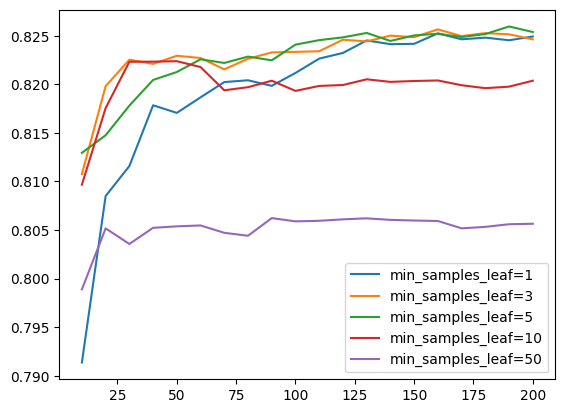

In [52]:
for s in [1, 3, 5, 10, 50]:
  df_subset = df_scores[df_scores.min_samples_leaf == s]
  plt.plot(df_subset.n_estimators, df_subset.auc, label='min_samples_leaf=%d' % s)

plt.legend()

In [53]:
min_samples_leaf = 3 #hard to choose, 3 and 5 kinda similar

##Final Random Forest

In [54]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=max_depth,
                            min_samples_leaf=min_samples_leaf,
                            random_state=1)
rf.fit(X_train, y_train)
y_pred_val = rf.predict_proba(X_val)[:, 1]
auc = roc_auc_score(y_val, y_pred_val)
auc

np.float64(0.8246258264512848)

#Gradient Boosting / XGBoost

In [69]:
features = dv.get_feature_names_out().tolist()
dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=features)
dval = xgb.DMatrix(X_val, label=y_val, feature_names=features)

In [70]:
watchlist = [(dtrain, 'train'), (dval, 'val')]

In [75]:
%%capture output

xgb_params = {
    'eta': 0.3,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthreads': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [76]:
y_pred_val = model.predict(dval)

In [77]:
roc_auc_score(y_val, y_pred_val)

np.float64(0.8045064299726334)

In [92]:
print(s[:200])

[0]	train-auc:0.86632	val-auc:0.77998
[5]	train-auc:0.93359	val-auc:0.81150
[10]	train-auc:0.95391	val-auc:0.82002
[15]	train-auc:0.97087	val-auc:0.82220
[20]	train-auc:0.97677	val-auc:0.82239
[25]	tr


In [93]:
def parse_xgb_output(output):
    results = []

    for line in output.stdout.strip().split('\n'):
        it_line, train_line, val_line = line.split('\t')

        it = int(it_line.strip('[]'))
        train = float(train_line.split(':')[1])
        val = float(val_line.split(':')[1])

        results.append((it, train, val))

    columns = ['num_iter', 'train_auc', 'val_auc']
    df_results = pd.DataFrame(results, columns=columns)
    return df_results

In [94]:
df_score = parse_xgb_output(output)
df_score.head()

,num_iter,train_auc,val_auc
0,0,0.86632,0.77998
1,5,0.93359,0.81150
2,10,0.95391,0.82002
3,15,0.97087,0.82220
4,20,0.97677,0.82239


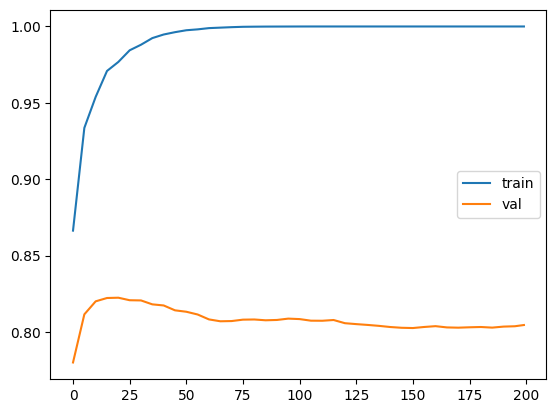

In [95]:
plt.plot(df_score.num_iter, df_score.train_auc, label='train')
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

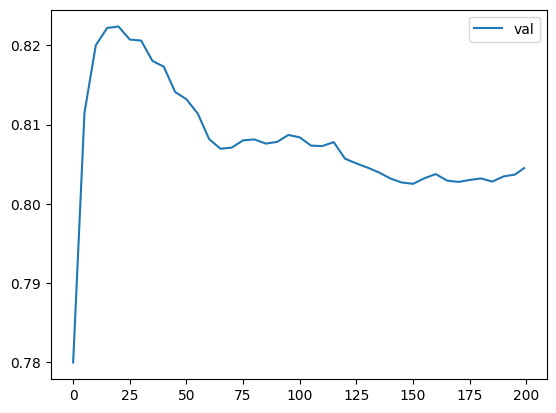

In [96]:
plt.plot(df_score.num_iter, df_score.val_auc, label='val')
plt.legend()

##XGBoost Parameter Tuning

###Tune eta

In [98]:
scores = {}

In [113]:
%%capture output

xgb_params = {
    'eta': 0.01,
    'max_depth': 6,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthreads': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [114]:
key = 'eta=%s' % (xgb_params['eta'])
scores[key] = parse_xgb_output(output)

In [115]:
scores['eta=0.01']

,num_iter,train_auc,val_auc
0,0,0.86632,0.77998
1,5,0.87007,0.77821
2,10,0.87208,0.77838
3,15,0.87381,0.78277
4,20,0.87584,0.78719
5,25,0.88595,0.79571
6,30,0.89329,0.80000
7,35,0.89642,0.79971
8,40,0.89881,0.79866
9,45,0.90066,0.79690


In [116]:
scores.keys()

dict_keys(['eta=0.3', 'eta=1.0', 'eta=0.1', 'eta=0.05', 'eta=0.01'])

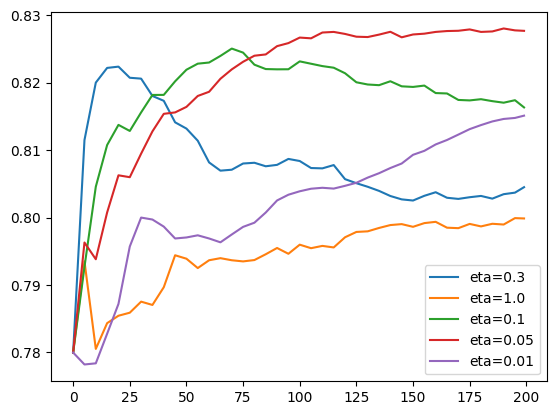

In [117]:
for key, df_score in scores.items():
  plt.plot(df_score.num_iter, df_score.val_auc, label=key)
plt.legend()

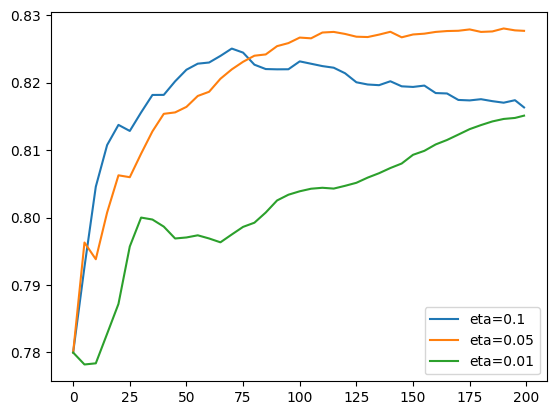

In [121]:
etas = ['eta=0.1', 'eta=0.05', 'eta=0.01']

for eta in etas:
  df_score = scores[eta]
  plt.plot(df_score.num_iter, df_score.val_auc, label=eta)
plt.legend()

###Tune max_depth

In [146]:
scores = {}

In [156]:
%%capture output

xgb_params = {
    'eta': 0.05,
    'max_depth': 10,
    'min_child_weight': 1,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthreads': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [157]:
key = 'max_depth=%s' % (xgb_params['max_depth'])
scores[key] = parse_xgb_output(output)

In [161]:
del scores['max_depth=10']

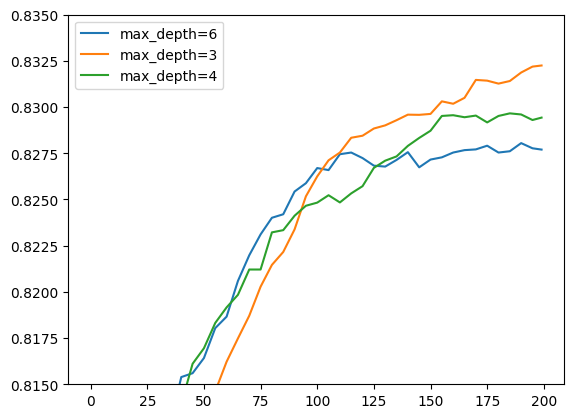

In [167]:
for max_depth, df_score in scores.items():
  plt.plot(df_score.num_iter, df_score.val_auc, label=max_depth)

plt.ylim(0.815, 0.835)
plt.legend()

###Tune min_child_weight

In [168]:
scores = {}

In [175]:
%%capture output

xgb_params = {
    'eta': 0.05,
    'max_depth': 3,
    'min_child_weight': 30,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthreads': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=200,
                  verbose_eval=5,
                  evals=watchlist)

In [176]:
key = 'min_child_weight=%s' % (xgb_params['min_child_weight'])
scores[key] = parse_xgb_output(output)

In [177]:
key

'min_child_weight=30'

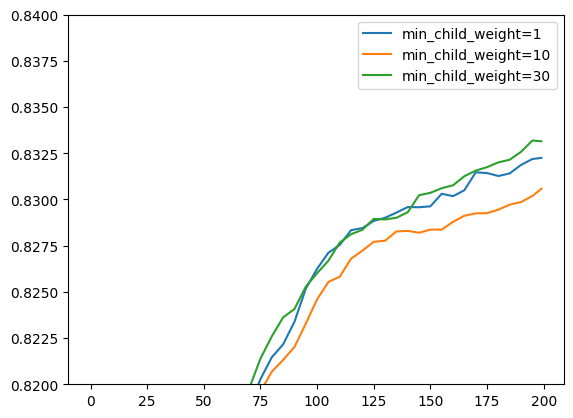

In [181]:
for min_child_weight, df_score in scores.items():
  plt.plot(df_score.num_iter, df_score.val_auc, label=min_child_weight)

plt.ylim(0.82, 0.84)
plt.legend()

##Final XGBoost model

In [182]:
xgb_params = {
    'eta': 0.05,
    'max_depth': 3,
    'min_child_weight': 30,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthreads': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=200)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:31:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "nthreads" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [183]:
y_pred_val = model.predict(dval)
roc_auc_score(y_val, y_pred_val)

np.float64(0.8331506865902982)

# Selecting final model

##Compare AUC scores between tuned models

In [187]:
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=15)
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=10, min_samples_leaf=15)

In [188]:
y_pred_val = dt.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred_val)

np.float64(0.7911984451817587)

In [189]:
rf = RandomForestClassifier(n_estimators=200,
                            max_depth=10,
                            min_samples_leaf=3,
                            random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, min_samples_leaf=3, n_estimators=200,
                       random_state=1)

In [190]:
y_pred_val = rf.predict_proba(X_val)[:, 1]
roc_auc_score(y_val, y_pred_val)

np.float64(0.8246258264512848)

In [191]:
xgb_params = {
    'eta': 0.05,
    'max_depth': 3,
    'min_child_weight': 30,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthreads': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dtrain,
                  num_boost_round=200)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:52:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "nthreads" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [192]:
y_pred_val = model.predict(dval)
roc_auc_score(y_val, y_pred_val)

np.float64(0.8331506865902982)

##Train on full set, test

In [193]:
df_full_train

,status,seniority,home,time,age,marital,records,job,expenses,income,assets,debt,amount,price
0,ok,22,owner,48,48,married,no,fixed,60,110.0,3000.0,0.0,1000,1460
1,default,8,other,60,41,married,no,freelance,45,62.0,0.0,0.0,1800,2101
2,ok,2,parents,36,19,married,no,fixed,35,162.0,4000.0,100.0,400,570
3,ok,1,owner,12,61,married,no,others,45,103.0,20000.0,0.0,300,650
4,ok,13,owner,60,27,married,no,fixed,35,253.0,7000.0,0.0,1060,1750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3558,default,4,owner,60,47,married,no,freelance,75,0.0,13500.0,0.0,1900,1976
3559,ok,2,rent,60,28,single,no,fixed,45,101.0,0.0,0.0,1300,1333
3560,ok,2,parents,36,25,single,no,fixed,35,110.0,0.0,0.0,500,1200
3561,ok,4,other,60,25,single,no,fixed,35,162.0,0.0,0.0,1800,2999


In [195]:
y_full_train = (df_full_train.status == 'default').astype(int).values
y_full_train

array([0, 1, 0, ..., 0, 0, 1])

In [196]:
del df_full_train['status']

In [197]:
dicts_full_train = df_full_train.to_dict(orient='records')
dv = DictVectorizer(sparse=False)
X_full_train = dv.fit_transform(dicts_full_train)

dicts_test = df_test.to_dict(orient='records')
X_test = dv.transform(dicts_test)

In [199]:
features = dv.get_feature_names_out().tolist()
dfulltrain = xgb.DMatrix(X_full_train, label=y_full_train, feature_names=features)
dtest = xgb.DMatrix(X_test, feature_names=features)

In [200]:
xgb_params = {
    'eta': 0.05,
    'max_depth': 3,
    'min_child_weight': 30,
    'objective': 'binary:logistic',
    'eval_metric': 'auc',
    'nthreads': 8,
    'seed': 1,
    'verbosity': 1
}

model = xgb.train(xgb_params, dfulltrain,
                  num_boost_round=200)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:07:38] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "nthreads" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [201]:
y_pred_test = model.predict(dtest)
roc_auc_score(y_test, y_pred_test)

np.float64(0.8340684717266995)